In [10]:
from ase.thermochemistry import IdealGasThermo, HarmonicThermo

In [11]:
from landau.phases import AsePhase

In [12]:
import numpy as np

In [13]:
import matplotlib.pyplot as plt

In [14]:
from ase.build import molecule

In [15]:
from ase import Atoms
from landau.phases import IdealSolution, LinePhase, SlowInterpolatingPhase

In [98]:
sa = AsePhase('Cu(s)', 0.0, HarmonicThermo([.1, .1, .1], potentialenergy=-2))
sab = AsePhase('CuH(s)', 0.5, HarmonicThermo([.1, .1, .1], potentialenergy=-2.25))
sb = AsePhase('H(s)', 1.0, HarmonicThermo([.1, .1, .1], potentialenergy=-1.5))
s = SlowInterpolatingPhase('solid', [sa, sab, sb], add_entropy=True)

la = AsePhase('Cu(s)', 0.0, HarmonicThermo([.05]*3, potentialenergy=-1.8))
la3b = AsePhase('Cu3H(l)', 0.25, HarmonicThermo([.05]*3, potentialenergy=-2.15))
lab = AsePhase('CuH(l)', 0.5, HarmonicThermo([.05]*3, potentialenergy=-2.2))
l = SlowInterpolatingPhase('liquid', [la, la3b, lab], add_entropy=True)


im = LinePhase('CuH$_2$', 2/3, -2.25, .1e-5)

ga = AsePhase(
    'Cu(g)', 0.0, 
    IdealGasThermo(
        [], 'monatomic',
        potentialenergy=2,
        atoms=Atoms('Cu'), symmetrynumber=0, spin=0,
    ), 
    pressure=10000
)
gb = AsePhase(
    'H(g)', 1.0, 
    IdealGasThermo(
        [.2], 'linear',
        potentialenergy=-1.5,
        atoms=molecule('H2'), symmetrynumber=2, spin=0,
    ), 
    pressure=10000
)
g = IdealSolution('gas', ga, gb)

In [99]:
t = np.linspace(10, 1000)

In [100]:
m = np.linspace(-2, 2, 100)

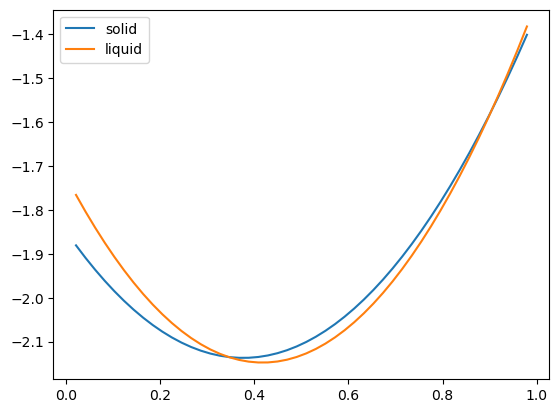

In [101]:
cc = np.linspace(0, 1)[1:-1]
for p in (s, l):
    plt.plot(cc, p.free_energy(100, cc), label=p.name)
plt.legend()

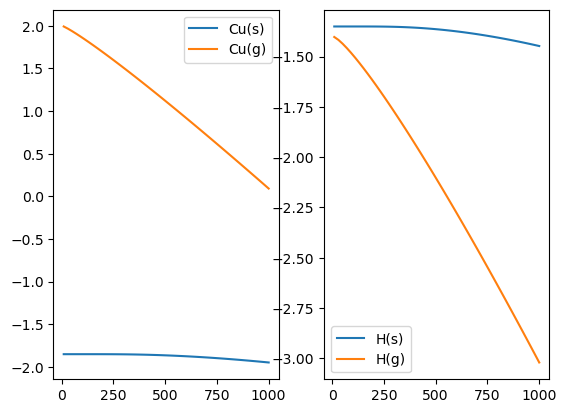

In [102]:
plt.subplot(121)
for p in (sa, ga):
    plt.plot(t, p.line_free_energy(t), label=p.name)
plt.legend()
plt.subplot(122)
for p in (sb, gb):
    plt.plot(t, p.line_free_energy(t), label=p.name)
plt.legend()

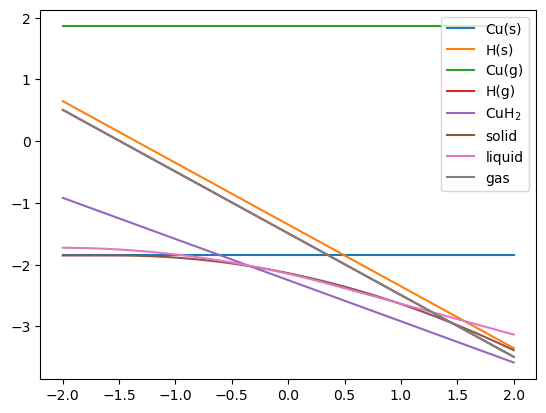

In [103]:
for p in (sa, sb, ga, gb, im, s, l, g):
    plt.plot(m, p.semigrand_potential(100, m), label=p.name)
plt.legend()

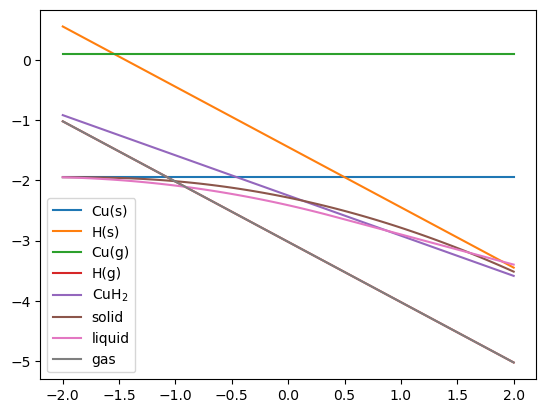

In [104]:
for p in (sa, sb, ga, gb, im, s, l, g):
    plt.plot(m, p.semigrand_potential(1000, m), label=p.name)
plt.legend()

In [108]:
from landau.calculate import calc_phase_diagram

In [109]:
from landau.plot import plot_phase_diagram, plot_mu_phase_diagram

In [110]:
df = calc_phase_diagram(
    [s, l, g, im], 
    Ts=np.linspace(10, 1750, 50), 
    mu=np.linspace(-2.5, 3, 100), 
    keep_unstable=True
)

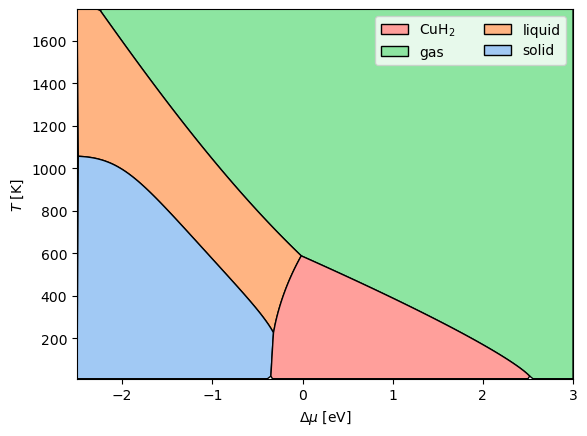

In [111]:
plot_mu_phase_diagram(df, poly_method='fasttsp')

<timed eval>:1: DeprecationWarning: landau.plot.plot_phase_diagram(min_c_width=0.01) is deprecated.


CPU times: user 2.43 s, sys: 61.7 ms, total: 2.49 s
Wall time: 2.49 s


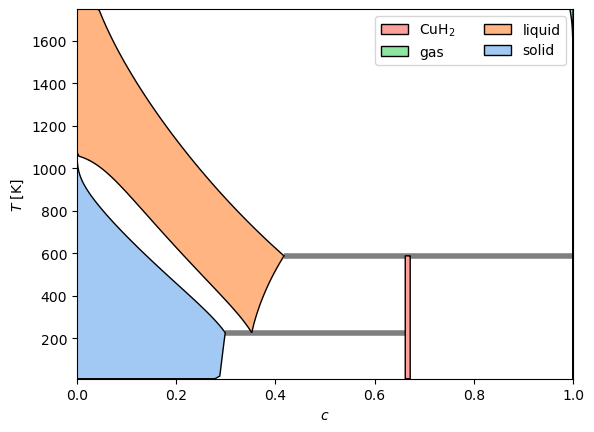

In [112]:
%%time
plot_phase_diagram(df, poly_method='fasttsp', tielines=True, min_c_width=.01)

<timed eval>:1: DeprecationWarning: landau.plot.plot_phase_diagram(min_c_width=0.01) is deprecated.


CPU times: user 363 ms, sys: 996 μs, total: 364 ms
Wall time: 365 ms


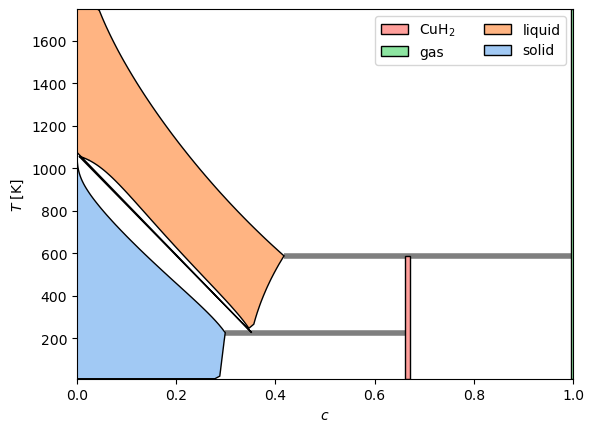

In [113]:
%%time
plot_phase_diagram(df, poly_method='segments', tielines=True, min_c_width=.01)